In [1]:
import os
import math
import itertools
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision.datasets import ImageFolder
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from transformers import get_cosine_schedule_with_warmup

### Diffusion Sampler

Implements forward (noise addition) and reverse (denoising) processes in DDPM.

- **Noise Schedule:**  
  $\beta_t \in [10^{-4}, 0.02]$,  
  $\alpha_t = 1 - \beta_t$,  
  $\bar{\alpha}_t = \prod \alpha_t$

- **Forward Process:**  
  $x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon$

- **Reverse Process:**  
  $x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left(x_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}}\, \epsilon_\theta \right) + \sigma_t z$

In [2]:
class Sampler():

    def __init__(self, num_training_steps, device="cpu"):

        self.num_training_steps = num_training_steps
        self.device = device

        beta = torch.linspace(1e-4, 0.02, num_training_steps, device=device)

        alpha = 1 - beta
        alpha_cumulative_prod = torch.cumprod(alpha, dim=0)

        self.alpha = alpha
        self.beta = beta
        self.alpha_cumulative_prod = alpha_cumulative_prod


    def _repeated_unsqueeze(self, reference_tensor, tensor):
        while reference_tensor.dim() > tensor.dim():
            tensor = tensor.unsqueeze(-1)
        return tensor


    def add_noise(self, inputs, timesteps):

        alpha_cumulative_prod_timesteps = self.alpha_cumulative_prod[timesteps]

        mean_coeff = torch.sqrt(alpha_cumulative_prod_timesteps)
        var_coeff = torch.sqrt(1 - alpha_cumulative_prod_timesteps)

        mean_coeff = self._repeated_unsqueeze(inputs, mean_coeff)
        var_coeff = self._repeated_unsqueeze(inputs, var_coeff)

        noise = torch.randn_like(inputs)

        noisy_image = mean_coeff * inputs + var_coeff * noise

        return noisy_image, noise


    def remove_noise(self, x, t, pred_noise):
    
        beta_t = self.beta[t]
        alpha_t = self.alpha[t]
        alpha_bar_t = self.alpha_cumulative_prod[t]
    

        beta_t = self._repeated_unsqueeze(x, beta_t)
        alpha_t = self._repeated_unsqueeze(x, alpha_t)
        alpha_bar_t = self._repeated_unsqueeze(x, alpha_bar_t)
 
        mean = (1 / torch.sqrt(alpha_t)) * (
            x - (beta_t / torch.sqrt(1 - alpha_bar_t + 1e-8)) * pred_noise
        )
    

        noise = torch.randn_like(x)
        sigma = torch.sqrt(beta_t)
    

        is_t0 = (t == 0).float().view(-1, 1, 1, 1)
    
        return mean + (1 - is_t0) * sigma * noise

### Transformer Block (Attention + MLP)

Implements a vision-style transformer block for spatial feature processing.

- **Self-Attention:**
  - Multi-head attention over flattened spatial tokens
  - Supports fused scaled dot-product attention
  - Learns global dependencies across the image

- **MLP Block:**
  - Two-layer feedforward network with GELU activation
  - Expands and projects features

- **Structure:**
  - Input: $(B, C, H, W)$ → reshaped to $(B, HW, C)$
  - LayerNorm → Attention → Residual
  - LayerNorm → MLP → Residual
  - Reshape back to $(B, C, H, W)$

- Captures both local and global spatial interactions, useful for diffusion models and image reconstruction.

In [4]:
class SelfAttention(nn.Module):

  def __init__(self,
               in_channels,
               num_heads=12, 
               attn_p=0,
               proj_p=0,
               fused_attn=True):

    super().__init__()
    assert in_channels % num_heads == 0
    self.num_heads = num_heads
    self.head_dim = int(in_channels / num_heads)
    self.scale = self.head_dim ** -0.5
    self.fused_attn = fused_attn  

    self.qkv = nn.Linear(in_channels, in_channels*3)
    self.attn_p = attn_p
    self.attn_drop = nn.Dropout(attn_p)
    self.proj = nn.Linear(in_channels, in_channels)
    self.proj_drop = nn.Dropout(proj_p)

  def forward(self, x):
    batch_size, seq_len, embed_dim = x.shape
      
    qkv = self.qkv(x).reshape(batch_size, seq_len, 3, self.num_heads, self.head_dim)
    qkv = qkv.permute(2,0,3,1,4)
    q,k,v = qkv.unbind(0)

    if self.fused_attn:
      x = F.scaled_dot_product_attention(q,k,v, dropout_p=self.attn_p)
    else:
      attn = (q @ k.transpose(-2,-1)) * self.scale
      attn = attn.softmax(dim=-1)
      attn = self.attn_drop(attn)
      x = attn @ v
    
    x = x.transpose(1,2).reshape(batch_size, seq_len, embed_dim)
    x = self.proj(x)
    x = self.proj_drop(x)
    
    return x

class MLP(nn.Module):
    def __init__(self, 
                 in_channels,
                 mlp_ratio=4, 
                 act_layer=nn.GELU,
                 mlp_p=0):

        super().__init__()
        hidden_features = int(in_channels * mlp_ratio)
        self.fc1 = nn.Linear(in_channels, hidden_features)
        self.act = act_layer()
        self.drop1 = nn.Dropout(mlp_p)
        self.fc2 = nn.Linear(hidden_features, in_channels)
        self.drop2 = nn.Dropout(mlp_p)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop1(x)
        x = self.fc2(x)
        x = self.drop2(x)
        return x
        
class TransformerBlock(nn.Module):
    def __init__(self,
                 in_channels,
                 fused_attention=True,
                 num_heads=4, 
                 mlp_ratio=2,
                 proj_p=0,
                 attn_p=0,
                 mlp_p=0,
                 act_layer=nn.GELU,
                 norm_layer=nn.LayerNorm):
        
        super().__init__()
        self.norm1 = norm_layer(in_channels, eps=1e-6)

        self.attn = SelfAttention(in_channels=in_channels,
                                  num_heads=num_heads, 
                                  attn_p=attn_p,
                                  proj_p=proj_p,
                                  fused_attn=fused_attention)
        
        self.norm2 = norm_layer(in_channels, eps=1e-6)
        self.mlp = MLP(in_channels=in_channels,
                       mlp_ratio=mlp_ratio,
                       act_layer=act_layer,
                       mlp_p=mlp_p)
        
    def forward(self, x):
        batch_size, channels, height, width = x.shape
      
        
        x = x.reshape(batch_size, channels, height*width).permute(0,2,1)
        
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))

        x = x.permute(0,2,1).reshape(batch_size, channels, height, width)
        return x

rand_img = torch.randn(4,32,64,64)
t = TransformerBlock(in_channels=32)
t(rand_img).shape

torch.Size([4, 32, 64, 64])

### Sinusoidal Time Embedding

Encodes diffusion timesteps into high-dimensional representations.

- **Sinusoidal Encoding:**
  - Uses sine and cosine functions at different frequencies
  - Similar to positional encoding in transformers

- **Formulation:**
  - $\text{Embedding}(t) = [\sin(t \cdot \omega), \cos(t \cdot \omega)]$

- **MLP Projection:**
  - Embeddings are passed through an MLP with SiLU activation
  - Produces richer, learnable time representations

- Provides timestep information to the model, enabling it to condition on the diffusion step during denoising.

In [5]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, time_embed_dim, scaled_time_embed_dim):
        super().__init__()
        self.inv_freqs = nn.Parameter(1.0 / (10000 ** (torch.arange(0, time_embed_dim, 2).float() / (time_embed_dim/2))), requires_grad=False)
        
        self.time_mlp = nn.Sequential(nn.Linear(time_embed_dim, scaled_time_embed_dim), 
                                      nn.SiLU(), 
                                      nn.Linear(scaled_time_embed_dim, scaled_time_embed_dim), 
                                      nn.SiLU())
    def forward(self, timesteps):
        timestep_freqs = timesteps.unsqueeze(1) * self.inv_freqs.unsqueeze(0)
        embeddings = torch.cat([torch.sin(timestep_freqs), torch.cos(timestep_freqs)], axis=-1)
        embeddings = self.time_mlp(embeddings)
        return embeddings

s = SinusoidalTimeEmbedding(time_embed_dim=128,scaled_time_embed_dim=256)
timesteps = torch.tensor([1,2,3])
s(timesteps).shape

torch.Size([3, 256])

### Upsample Block

Performs spatial upsampling in the decoder of the network.

- **Operation:**
  - Upsamples feature maps by a factor of 2
  - Followed by a $3 \times 3$ convolution for refinement

- **Structure:**
  - Upsample → Conv2D

- **Input / Output:**
  - Input: $(B, C, H, W)$  
  - Output: $(B, C, 2H, 2W)$  

- Used in the expanding path to recover spatial resolution while preserving learned features.

In [7]:
class UpSampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding='same')
        )

    def forward(self, inputs):
        batch, channels, height, width = inputs.shape
        upsampled = self.upsample(inputs)
        assert (upsampled.shape == (batch, channels, height*2, width*2))
        return upsampled

### Residual Block with Time Conditioning

Core building block for diffusion models with temporal conditioning.

- **Structure:**
  - GroupNorm → SiLU → Conv → Time Injection  
  - GroupNorm → SiLU → Conv → Residual Add  

- **Time Conditioning:**
  - Timestep embeddings are projected and added to feature maps
  - Enables the model to adapt behavior across diffusion steps

- **Residual Connection:**
  - Skip connection ensures stable training
  - Uses $1 \times 1$ conv if channel dimensions differ

- **Input / Output:**
  - Input: $(B, C, H, W)$  
  - Output: $(B, C', H, W)$  

- Combines **spatial feature extraction + temporal awareness**, essential for denoising in diffusion models.

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, groupnorm_num_groups, time_embed_dim):
        super().__init__()
        

        self.time_expand = nn.Linear(time_embed_dim, out_channels)


        self.groupnorm_1 = nn.GroupNorm(groupnorm_num_groups, in_channels)
        self.conv_1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same")


        self.groupnorm_2 = nn.GroupNorm(groupnorm_num_groups, out_channels)
        self.conv_2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same")

 
        self.residual_connection = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, time_embeddings):

        residual_connection = x


        time_embed = self.time_expand(time_embeddings)

        x = self.groupnorm_1(x)
        x = F.silu(x)
        x = self.conv_1(x)

  
        x = x + time_embed.reshape((*time_embed.shape, 1, 1))


        x = self.groupnorm_2(x)
        x = F.silu(x)
        x = self.conv_2(x)


        x = x + self.residual_connection(residual_connection)
        
        return x
        

### Conditional U-Net (Diffusion Backbone)

U-Net architecture for noise prediction in diffusion models with time conditioning and attention.

- **Input / Output:**
  - Input: $(B, C_{in}, H, W)$ (noisy image + condition)
  - Output: $(B, C_{out}, H, W)$ (predicted noise)

- **Encoder (Downsampling Path):**
  - Residual blocks with time conditioning
  - Downsampling via strided convolutions
  - Transformer-based attention at multiple scales

- **Bottleneck:**
  - Residual blocks at lowest resolution
  - Captures global context

- **Decoder (Upsampling Path):**
  - Upsampling + residual blocks
  - Skip connections from encoder (U-Net structure)
  - Attention layers for feature refinement

- **Key Features:**
  - Time embeddings injected into residual blocks
  - Multi-scale feature learning
  - Combines convolution + attention

- Learns to map noisy inputs to predicted noise $\epsilon_\theta$, enabling iterative denoising in diffusion.

In [9]:
class UNET(nn.Module):
    def __init__(self, in_channels=6, out_channels=3,
                 start_dim=64, dim_mults=(1,2,4),
                 residual_blocks_per_group=1,
                 groupnorm_num_groups=16,
                 time_embed_dim=128):
        super().__init__()

        self.input_image_channels = in_channels
        self.output_image_channels = out_channels
        

        channel_sizes = [start_dim*i for i in dim_mults]
        starting_channel_size, ending_channel_size = channel_sizes[0], channel_sizes[-1]

  
        self.encoder_config = []
        
        for idx, d in enumerate(channel_sizes):

            for _ in range(residual_blocks_per_group):
                self.encoder_config.append(((d, d), "residual")) 

            self.encoder_config.append(((d,d), "downsample")) 


            self.encoder_config.append((d, "attention"))
            

            if idx < len(channel_sizes) - 1:
                self.encoder_config.append(((d,channel_sizes[idx+1]), "residual"))
            

        self.bottleneck_config = []
        for _ in range(residual_blocks_per_group):
            self.bottleneck_config.append(((ending_channel_size, ending_channel_size), "residual"))

        out_dim = ending_channel_size


        reversed_encoder_config = self.encoder_config[::-1]


        self.decoder_config = []
        for idx, (metadata, type) in enumerate(reversed_encoder_config):

            if type != "attention":
                enc_in_channels, enc_out_channels = metadata
            
                self.decoder_config.append(((out_dim+enc_out_channels, enc_in_channels), "residual"))
                        
                if type == "downsample":

                    self.decoder_config.append(((enc_in_channels, enc_in_channels), "upsample"))
    

                out_dim = enc_in_channels
            else:
                in_channels = metadata
                self.decoder_config.append((in_channels, "attention"))


        self.decoder_config.append(((starting_channel_size*2, starting_channel_size), "residual"))
        
        

        self.conv_in_proj = nn.Conv2d(self.input_image_channels, 
                                      starting_channel_size, 
                                      kernel_size=3, 
                                      padding="same")
        
        self.encoder = nn.ModuleList()
        for metadata, type in self.encoder_config:
            if type == "residual":
                in_channels, out_channels = metadata
                self.encoder.append(ResidualBlock(in_channels=in_channels,
                                                  out_channels=out_channels,
                                                  groupnorm_num_groups=groupnorm_num_groups,
                                                  time_embed_dim=time_embed_dim))
            elif type == "downsample":
                in_channels, out_channels = metadata
                self.encoder.append(
                    nn.Conv2d(in_channels, 
                              out_channels, 
                              kernel_size=3, 
                              stride=2, 
                              padding=1)
                    )
            elif type == "attention":
                in_channels = metadata
                self.encoder.append(TransformerBlock(in_channels))

        

        self.bottleneck = nn.ModuleList()
        
        for (in_channels, out_channels), _ in self.bottleneck_config:
            self.bottleneck.append(ResidualBlock(in_channels=in_channels,
                                                 out_channels=out_channels,
                                                 groupnorm_num_groups=groupnorm_num_groups,
                                                 time_embed_dim=time_embed_dim))


        self.decoder = nn.ModuleList()
        for metadata, type in self.decoder_config:
            if type == "residual":
                in_channels, out_channels = metadata
                self.decoder.append(ResidualBlock(in_channels=in_channels,
                                                  out_channels=out_channels,
                                                  groupnorm_num_groups=groupnorm_num_groups,
                                                  time_embed_dim=time_embed_dim))
            elif type == "upsample":
                in_channels, out_channels = metadata
                self.decoder.append(UpSampleBlock(in_channels=in_channels, 
                                                  out_channels=out_channels))

            elif type == "attention":
                in_channels = metadata
                self.decoder.append(TransformerBlock(in_channels))


        self.conv_out_proj = nn.Conv2d(in_channels=starting_channel_size, 
                                       out_channels=self.output_image_channels,
                                       kernel_size=3, 
                                       padding="same")

        
    def forward(self, x, time_embeddings):
        residuals = []


        x = self.conv_in_proj(x)
        residuals.append(x)


        for module in self.encoder:
            if isinstance(module, (ResidualBlock)):
                x = module(x, time_embeddings)
                residuals.append(x)
            elif isinstance(module, nn.Conv2d):
                x = module(x)
                residuals.append(x)
            else:
                x = module(x)


        for module in self.bottleneck:
            x = module(x, time_embeddings)


        for module in self.decoder:
            if isinstance(module, ResidualBlock):
                residual_tensor = residuals.pop()
                x  = torch.cat([x, residual_tensor], axis=1)
                x = module(x, time_embeddings)
            else:
                x = module(x)

        x = self.conv_out_proj(x)
        
        return x

### Diffusion Model

End-to-end model for noise prediction in the diffusion process.

- **Components:**
  - **Sinusoidal Time Embedding:** Encodes timestep $t$ into high-dimensional features
  - **U-Net Backbone:** Predicts noise conditioned on input and timestep

- **Forward Pass:**
  - Input: noisy image $x_t$ and timestep $t$
  - Compute time embedding $e_t$
  - Predict noise: $\epsilon_\theta(x_t, t)$

- **Objective:**
  - Learn to approximate the noise added during forward diffusion

- **Pipeline:**
  - $t \rightarrow$ Time Embedding → U-Net → Noise Prediction

- Forms the core of the diffusion process, enabling iterative denoising and image reconstruction.

In [10]:
class Diffusion(nn.Module):
    def __init__(self, 
                 in_channels=3, 
                 start_dim=64, 
                 dim_mults=(1,2,4,4), 
                 residual_blocks_per_group=1, 
                 groupnorm_num_groups=16, 
                 time_embed_dim=128, 
                 time_embed_dim_ratio=2):

        super().__init__()
        self.in_channels = in_channels
        self.start_dim = start_dim
        self.dim_mults = dim_mults
        self.residual_blocks_per_group = residual_blocks_per_group
        self.groupnorm_num_groups = groupnorm_num_groups

        self.time_embed_dim = time_embed_dim
        self.scaled_time_embed_dim = int(time_embed_dim * time_embed_dim_ratio)

        self.sinusoid_time_embeddings = SinusoidalTimeEmbedding(time_embed_dim=self.time_embed_dim,
                                                                scaled_time_embed_dim=self.scaled_time_embed_dim)

        self.unet = UNET(
            in_channels=in_channels,   
            out_channels=3,            
            start_dim=start_dim,
            dim_mults=dim_mults,
            residual_blocks_per_group=residual_blocks_per_group,
            groupnorm_num_groups=groupnorm_num_groups,
            time_embed_dim=self.scaled_time_embed_dim
        )

    def forward(self, noisy_inputs, timesteps):


        timestep_embeddings = self.sinusoid_time_embeddings(timesteps)
        

        noise_pred = self.unet(noisy_inputs, timestep_embeddings)

        return noise_pred

### Sampling & Visualization

Generates high-resolution images from noise using the reverse diffusion process and visualizes intermediate steps.

- **Initialization:**
  - Start from random noise $x_T \sim \mathcal{N}(0, I)$
  - Condition on low-resolution input

- **Denoising Loop:**
  - For each timestep $t \rightarrow 0$:
    - Concatenate inputs: $[x_t, x_{LR}, x_t \cdot x_{LR}]$
    - Predict noise $\epsilon_\theta$
    - Update image using sampler

- **Visualization:**
  - Store intermediate outputs at fixed intervals
  - Plot progression from noise → reconstructed image

- **Output:**
  - Grid of generated samples saved as image
  - Tracks denoising trajectory across timesteps

- Demonstrates how the model progressively refines noise into structured high-resolution images.

In [11]:
@torch.no_grad()
def sample_plot_image(
        step_idx,
        total_timesteps,
        sampler,
        image_size,
        num_channels,
        plot_freq,
        model,
        num_gens,
        lr_condition,
        path_to_generated_dir,
        device
):

    import os
    import numpy as np
    import itertools
    import torch
    import matplotlib.pyplot as plt
    from torchvision import transforms

    model.eval()

    lr_condition = lr_condition.to(device)

    tensor2image_transform = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1) / 2),
        transforms.Lambda(lambda t: t.permute(1, 2, 0)),
        transforms.Lambda(lambda t: t * 255.),
        transforms.Lambda(lambda t: t.cpu().numpy().astype(np.uint8)),
        transforms.ToPILImage(),
    ])

    # start from random HR noise
    images = torch.randn(
        (num_gens, num_channels, image_size, image_size),
        device=device
    )

    num_images_per_gen = total_timesteps // plot_freq
    images_to_vis = [[] for _ in range(num_gens)]

    for t in reversed(range(total_timesteps)):

        ts = torch.full(
            (num_gens,),
            t,
            device=device,
            dtype=torch.long
        )


        model_input = torch.cat([
                images,
                lr_condition,
                images * lr_condition
            ], dim=1)

        noise_pred = model(model_input, ts)

        images = sampler.remove_noise(images, ts, noise_pred)

        if t % plot_freq == 0:

            for idx, image in enumerate(images):
                images_to_vis[idx].append(
                    tensor2image_transform(image)
                )

    images_to_vis = list(itertools.chain(*images_to_vis))

    fig, axes = plt.subplots(
        nrows=num_gens,
        ncols=num_images_per_gen,
        figsize=(num_images_per_gen, num_gens)
    )

    plt.tight_layout()

    for ax, image in zip(axes.ravel(), images_to_vis):
        ax.imshow(image)
        ax.axis("off")

    fig.subplots_adjust(wspace=0.05, hspace=0.05)

    save_path = os.path.join(
        path_to_generated_dir,
        f"step_{step_idx}.png"
    )

    plt.savefig(save_path)
    plt.close()

    model.train()

### Jet Dataset Loader

Custom PyTorch dataset for super-resolution of jet images.

- **Data:**
  - Loads paired low-resolution ($X_{LR}$) and high-resolution ($X_{HR}$) jet images
  - Supports train / validation / test splits

- **Preprocessing:**
  - Limits dataset size 
  - Converts NumPy arrays to PyTorch tensors
  - Resizes high-resolution images to $125 \times 125$

- **Output:**
  - Returns paired samples: $(X_{LR}, X_{HR})$

- Enables supervised learning for mapping low-resolution inputs to high-resolution targets.

In [ ]:
import torch
import numpy as np
import torch.nn.functional as F
from torch.utils.data import Dataset

class JetDataset(Dataset):

    def __init__(self, npz_path, split="train", max_samples=5000):

        data = np.load(npz_path)

        if split == "train":
            lr = data["X_LR_train"]
            hr = data["X_HR_train"]
        elif split == "val":
            lr = data["X_LR_val"]
            hr = data["X_HR_val"]
        else:
            lr = data["X_LR_test"]
            hr = data["X_HR_test"]

        lr = lr[:max_samples]
        hr = hr[:max_samples]

        self.lr = torch.from_numpy(lr).float()
        self.hr = torch.from_numpy(hr).float()


        self.hr = F.interpolate(
            self.hr,
            size=(128,128),
            mode="bilinear",
            align_corners=False
        )

    def __len__(self):
        return len(self.lr)

    def __getitem__(self, idx):
        return self.lr[idx], self.hr[idx]

### Training Pipeline

End-to-end training loop for conditional diffusion-based super-resolution.

- **Setup:**
  - Load jet dataset and dataloader
  - Initialize diffusion model, optimizer (AdamW), and cosine scheduler
  - Maintain EMA (Exponential Moving Average) of model weights

- **Training Step:**
  - Sample batch: $(X_{LR}, X_{HR})$
  - Upsample $X_{LR}$ to match HR resolution
  - Sample random timestep $t$
  - Add noise: $x_t = \text{add\_noise}(X_{HR}, t)$
  - Form input: $[x_t, X_{LR}, x_t \cdot X_{LR}]$
  - Predict noise $\epsilon_\theta$
  - Compute loss: $\mathcal{L} = \|\epsilon - \epsilon_\theta\|^2$

- **Optimization:**
  - Backpropagation + gradient clipping
  - Update EMA model for stable sampling
  - Learning rate scheduling

- **Evaluation:**
  - Periodically generate samples using EMA model
  - Visualize denoising progression

- **Checkpointing:**
  - Save model, EMA weights, optimizer, and scheduler states

- Trains the model to reconstruct high-resolution images from noisy inputs conditioned on low-resolution data.

In [13]:
def train(
        dataset_path="/kaggle/input/datasets/jahanravi03/jet-sr/jets_sr_preprocessed.npz",
        evaluation_interval=1000,
        total_timesteps=150,
        num_training_steps=30000,
        batch_size=16,
        lr=1e-4,
        max_samples=15000,
        path_to_generated="generated"
):

    torch.backends.cudnn.benchmark = True

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Using device:", device)

    os.makedirs(path_to_generated, exist_ok=True)

    dataset = JetDataset(
        dataset_path,
        split="train",
        max_samples=max_samples
    )

    trainloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    train_iter = iter(trainloader)

    model = Diffusion(
    in_channels=9,
    start_dim=32,
    dim_mults=(1,2,2)
        ).to(device)

    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("Number of parameters:", params)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=500,
        num_training_steps=num_training_steps
    )

    ema_model = copy.deepcopy(model)
    ema_model.eval()
    ema_decay = 0.999
    
    sampler = Sampler(num_training_steps=total_timesteps, device=device)

    loss_fn = nn.MSELoss()

    progress_bar = tqdm(range(num_training_steps))

    for step in progress_bar:

        try:
            lr_imgs, hr_imgs = next(train_iter)
        except StopIteration:
            train_iter = iter(trainloader)
            lr_imgs, hr_imgs = next(train_iter)

        lr_imgs = lr_imgs.to(device)
        hr_imgs = hr_imgs.to(device)

        batch_size = lr_imgs.shape[0]

        lr_up = F.interpolate(
            lr_imgs,
            size=hr_imgs.shape[-2:],
            mode="bilinear",
            align_corners=False
        )


        timesteps = torch.randint(
            0,
            total_timesteps,
            (batch_size,),
            device=device,
            dtype=torch.long
        )


        noisy_hr, noise = sampler.add_noise(hr_imgs, timesteps)


        model_input = torch.cat([
            noisy_hr,
            lr_up,
            noisy_hr * lr_up
        ], dim=1)


        noise_pred = model(model_input, timesteps)

        loss = loss_fn(noise_pred, noise)

        if torch.isnan(loss):
            optimizer.zero_grad()
            continue

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        with torch.no_grad():
            for p, ema_p in zip(model.parameters(), ema_model.parameters()):
                ema_p.data.mul_(ema_decay).add_(p.data, alpha=1 - ema_decay)
        scheduler.step()
        optimizer.zero_grad(set_to_none=True)

        progress_bar.set_postfix(loss=loss.detach().item())

   
        if step % evaluation_interval == 0 and step > 0:

            print(f"\nStep {step} | Loss {loss.detach().item():.6f}")


            lr_sample = lr_imgs[:4]

            lr_up_sample = F.interpolate(
                lr_sample,
                size=(128,128),
                mode="bilinear",
                align_corners=False
            )

            sample_plot_image(
                step_idx=step,
                total_timesteps=total_timesteps,
                sampler=sampler,
                image_size=128,
                num_channels=3,
                plot_freq=10,
                model=ema_model,
                num_gens=4,
                lr_condition=lr_up_sample,
                path_to_generated_dir=path_to_generated,
                device=device
            )
    torch.save({
    "model": model.state_dict(),
    "ema_model": ema_model.state_dict(),
    "optimizer": optimizer.state_dict(),
    "scheduler": scheduler.state_dict(),
            }, "diffusion_checkpoint.pt")

    print("Training completed")

In [14]:
train()

Using device: cuda
Number of parameters: 1735235


  0%|          | 0/30000 [00:00<?, ?it/s]


Step 1000 | Loss 0.040275

Step 2000 | Loss 0.057995

Step 3000 | Loss 0.018088

Step 4000 | Loss 0.023971

Step 5000 | Loss 0.024122

Step 6000 | Loss 0.038306

Step 7000 | Loss 0.014428

Step 8000 | Loss 0.014340

Step 9000 | Loss 0.009437

Step 10000 | Loss 0.013753

Step 11000 | Loss 0.007468

Step 12000 | Loss 0.010854

Step 13000 | Loss 0.014008

Step 14000 | Loss 0.007949

Step 15000 | Loss 0.007636

Step 16000 | Loss 0.007287

Step 17000 | Loss 0.009756

Step 18000 | Loss 0.007902

Step 19000 | Loss 0.024086

Step 20000 | Loss 0.007252

Step 21000 | Loss 0.009740

Step 22000 | Loss 0.006461

Step 23000 | Loss 0.013074

Step 24000 | Loss 0.010871

Step 25000 | Loss 0.007560

Step 26000 | Loss 0.009466

Step 27000 | Loss 0.011259

Step 28000 | Loss 0.006786

Step 29000 | Loss 0.010915
Training completed


### Inference & Visualization

Generates high-resolution images using the trained diffusion model.

- **Setup:**
  - Load trained EMA model checkpoint
  - Initialize sampler and dataset
  - Select a sample $(X_{LR}, X_{HR})$

- **Conditioning:**
  - Upsample $X_{LR}$ to match HR resolution

- **Sampling:**
  - Start from random noise $x_T \sim \mathcal{N}(0, I)$
  - Iteratively denoise:
    - Input: $[x_t, X_{LR}, x_t \cdot X_{LR}]$
    - Predict noise $\epsilon_\theta$
    - Update using sampler

- **Output:**
  - Generated high-resolution image
  - Visual comparison: LR vs Generated vs Ground Truth HR

- Demonstrates conditional generation and reconstruction capability of the diffusion model.

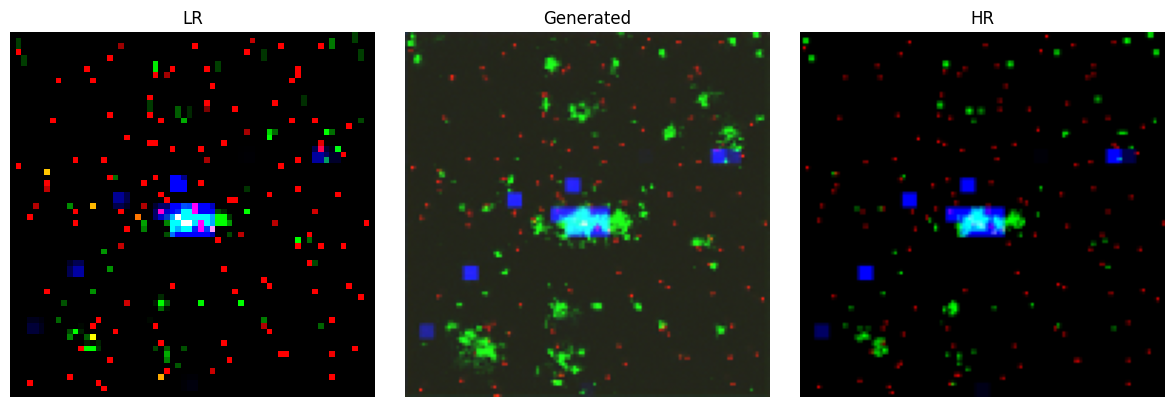

In [15]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import gc


device = "cuda" if torch.cuda.is_available() else "cpu"


gc.collect()
torch.cuda.empty_cache()


ckpt = torch.load("/kaggle/working/diffusion_checkpoint.pt", map_location=device)

model = Diffusion(
    in_channels=9,
    start_dim=32,
    dim_mults=(1,2,2)
        ).to(device)

model.load_state_dict(ckpt["ema_model"])
model.eval()


sampler = Sampler(num_training_steps=150, device=device)


dataset = JetDataset("/kaggle/input/datasets/jahanravi03/jet-sr/jets_sr_preprocessed.npz", split="train")

lr, hr = dataset[0]

lr = lr.unsqueeze(0).to(device)
hr = hr.unsqueeze(0).to(device)


lr_up = F.interpolate(
    lr,
    size=(128,128),
    mode="bilinear",
    align_corners=False
)


x = torch.randn_like(hr)

with torch.no_grad():
    for t in reversed(range(150)):
        ts = torch.tensor([t], device=device)

        model_input = torch.cat([
            x,
            lr_up,
            x * lr_up
        ], dim=1)

        noise_pred = model(model_input, ts)
        x = sampler.remove_noise(x, ts, noise_pred)

generated = x.detach()


def show(img, title):
    img = img.detach().cpu()
    img = ((img + 1) / 2).permute(1,2,0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
show(lr[0], "LR")

plt.subplot(1,3,2)
show(generated[0], "Generated")

plt.subplot(1,3,3)
show(hr[0], "HR")

plt.tight_layout()
plt.show()